# Lab 3 - Solution

## This notebook should be used in conjunction with the Canvas Quiz: Computational Physics Lab 3. Use the notebook to run scripts and make notes. Submit your final answers on Canvas.

# Part I: Solving the Simple Pendulum with Velocity-Verlet

These questions involve modifying simplependulum.ipynb from the third lecture, which uses RK4,  to instead use the Velocity-Verlet method (from the second lecture), and interpreting the results. 

In lectures, we considered the simple pendulum, which has the non-dimensional equation of motion $\frac{d^2\theta}{dt^2}=-4\pi^2\sin\theta,$ where $\theta =\theta (t)$ is the angle to the vertical at time $t.$ Note that the scaling of length and time is such that the period of small amplitude oscillations is $T_0=1.$

The code expproblem_and_simplependulum.ipynb from Lecture 3 integrates the pendulum equation of motion using fourth-order Runge-Kutta (RK4). Review the code and make sure you understand how it works.


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

def rhs_pend(x):

    #----------------------------------------------------------------------------
    # rhs_pend: Evaluate the right hand side of the coupled (non-
    #    dimensional) ODEs describing the nonlinear pendulum
    #
    #---INPUT:
    # x - the current value of the dependent variable. For the pendulum
    #    ODEs x = [theta omega] where theta is the angle and omega is the
    #    angular velocity.
    #    
    #---OUTPUT:
    # rhs - a row vector representing the value of the right hand side
    #    of the ODEs. Specifically, rhs=[omega -4*pi^2*sin(theta)].
    #-------------------------------------------------------------------------------
 
    
    rhs = np.zeros(2)
    
    theta = x[0];
    omega = x[1];
    rhs[0] = omega;
    rhs[1] = -4*np.pi**2*np.sin(theta)
    
    return rhs

## <span style="color:red">Q1</span>
### Modify the simplependulum.ipynb code so that it also plots $\theta$ versus $t.$ Run the code and produce $\theta$ versus $t$ plots for numerical integrations from $t=0$ to $t=7$ with time steps $\tau=0.01,\,0.1,\,0.2,\,1,$ and with initial angles $\theta_1=10,\,45,\,90,\,170\,{\rm deg}.$

For which time steps, and which initial angles, is the numerical solution *reasonably accurate*?

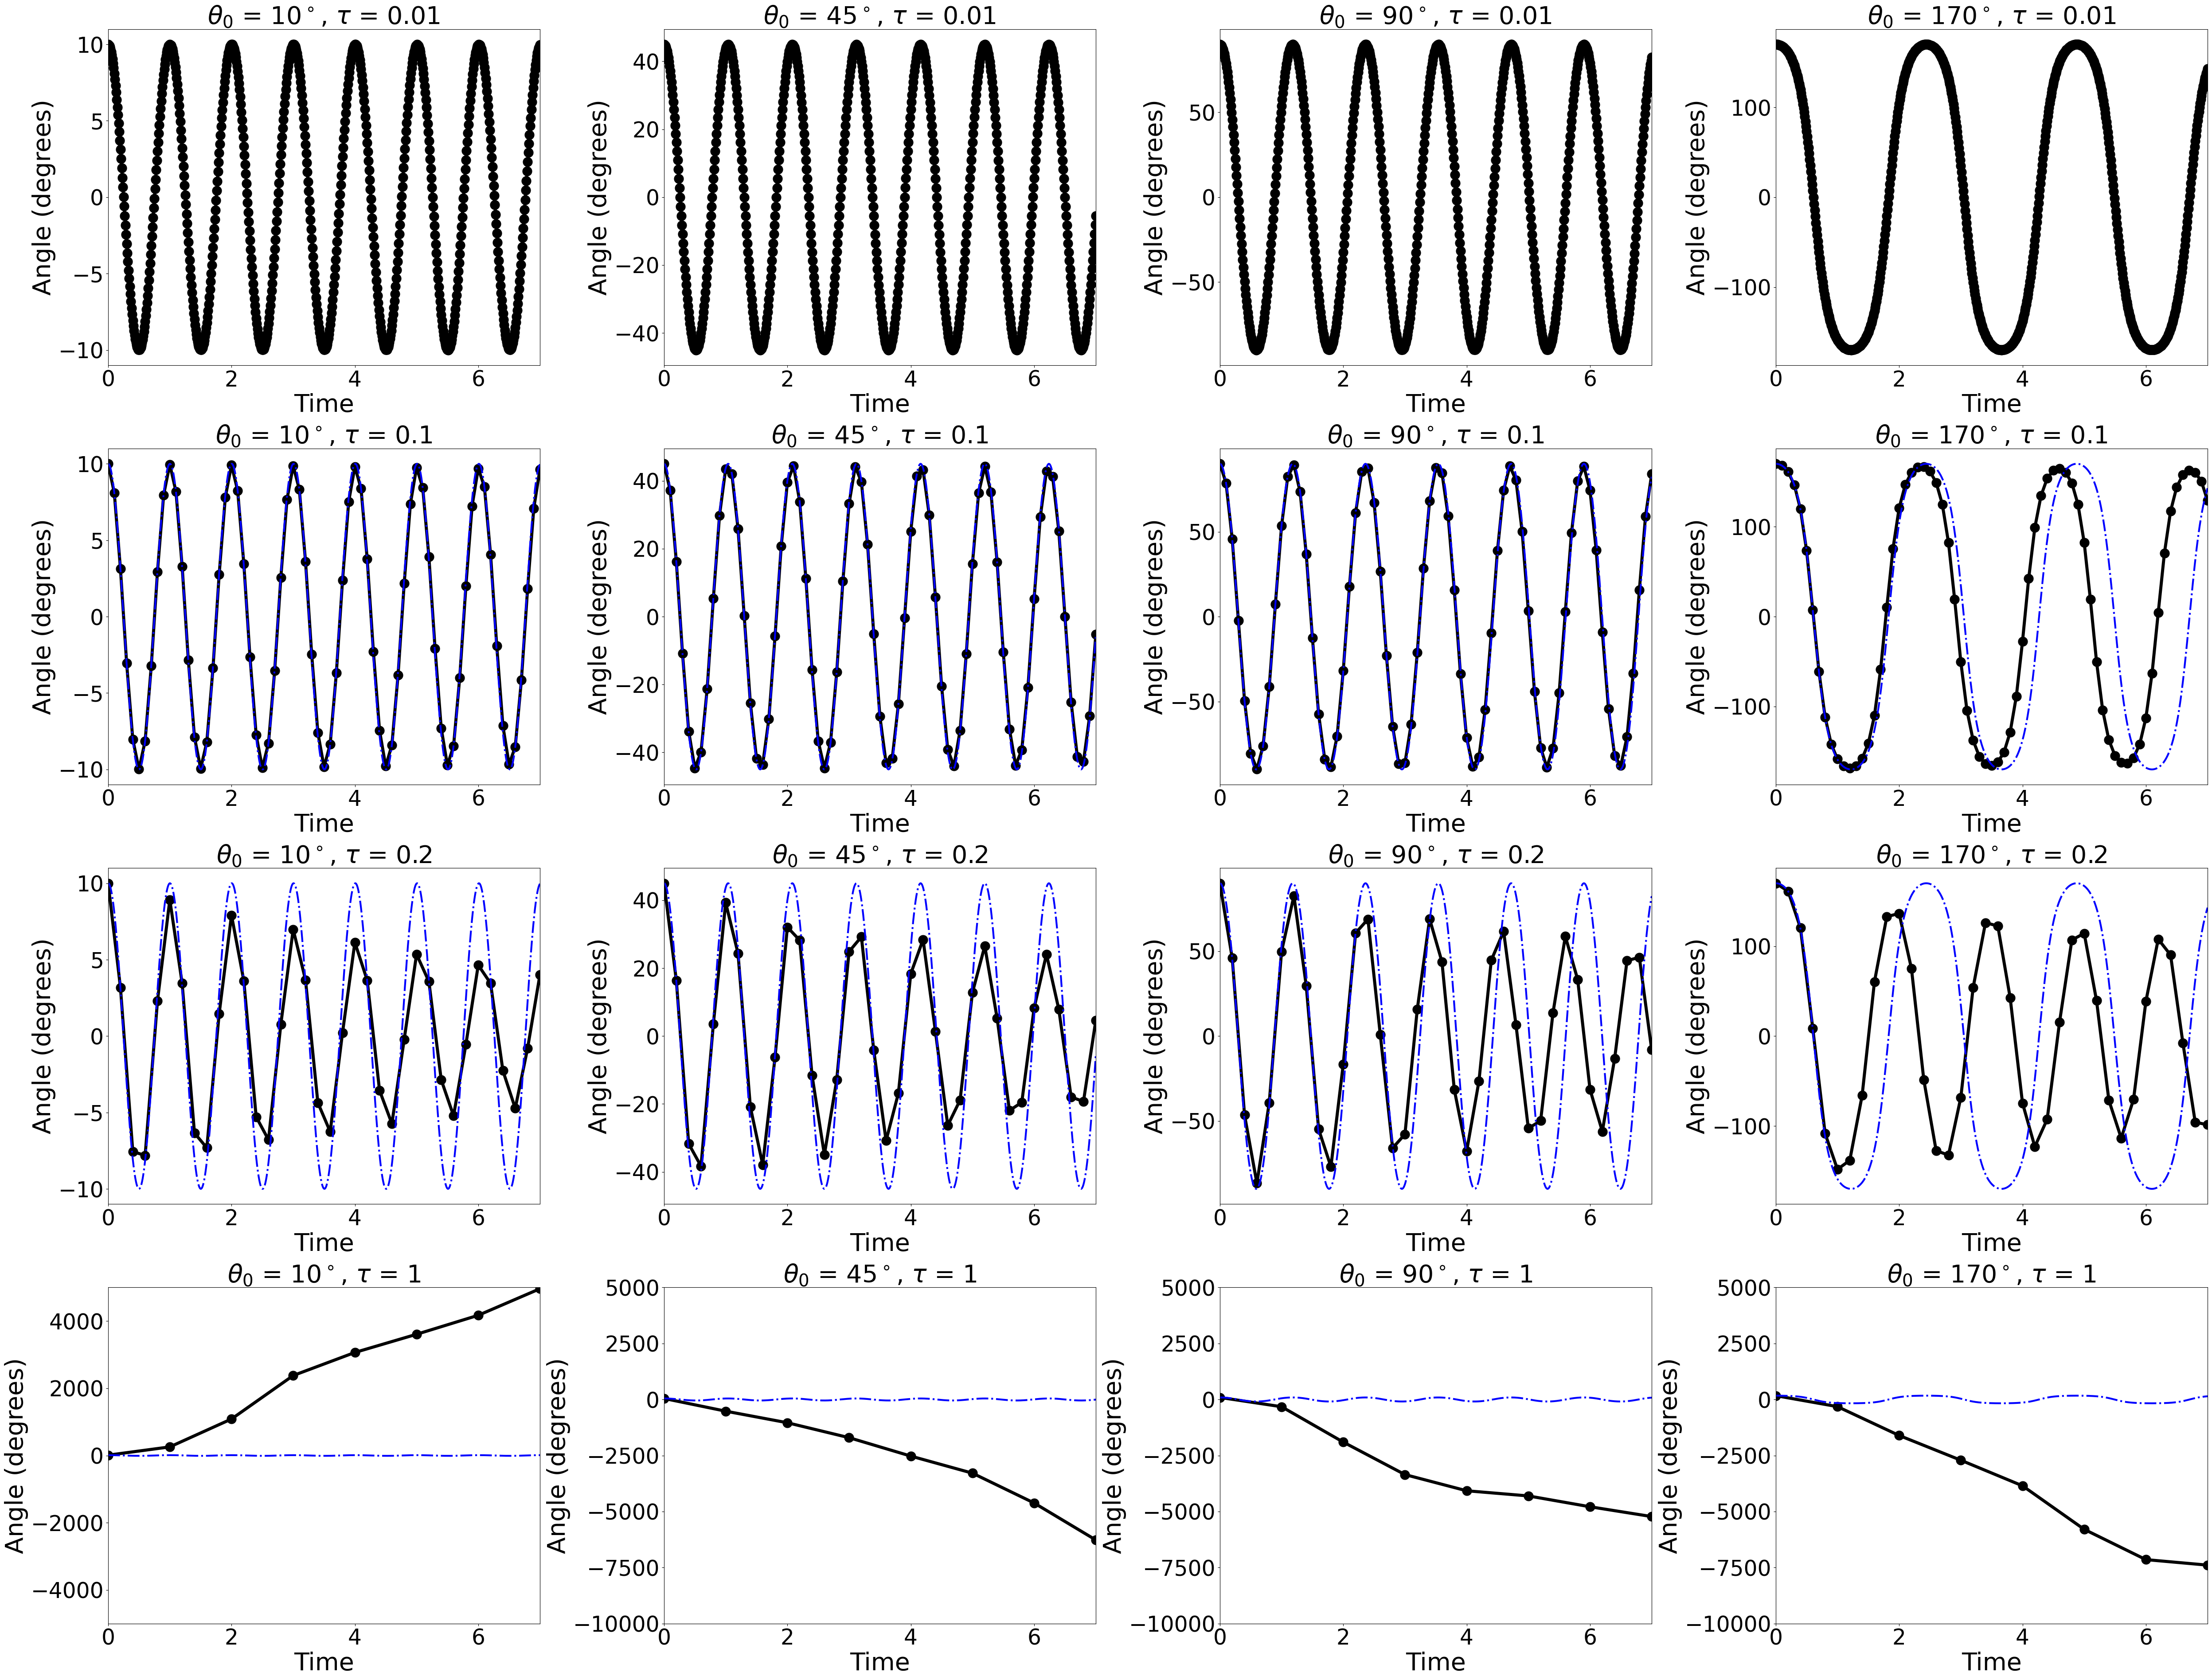

In [11]:
# You can copy/paste relevant parts from simplependulum.ipynb here and modify as needed

#-------------------------------------------------------------------------------
# !! Change initial parameters !! #
#-------------------------------------------------------------------------------
# Fourth-order Runge-Kutta integration
def theta_maker(theta_init):
    
    # Time grid parameters:
    tau_array = [0.01, 0.1, 0.2, 1]  # Time step
    
    theta_array_tot = []  # This will be a list of arrays of different lengths
    time_arrays = []      # Also, store the corresponding time arrays
    
    for i in range(len(tau_array)):
        #-------------------------------------------------------------------------------
        # Initial conditions
        theta = np.deg2rad(theta_init) # Initial angle in rad
        x = np.array([theta, 0])
        
        tau = tau_array[i]
        T = 7  # Total integration time 
        
        #(add +1 to ensure last step is included)
        numSteps = int(np.ceil(T/tau))  # Number of time steps
        theta_array = np.zeros(numSteps+1) 
        
        # Record initial angle before any steps
        theta_array[0] = x[0]
        
        #-------------------------------------------------------------------------------
        time = np.arange(numSteps+1)*tau
        time_arrays.append(time)  # Store the time array
                
        # Arrays to store pendulum positions
        xPendArray = np.zeros((numSteps+1, 2))
        yPendArray = np.zeros((numSteps+1, 2))
        
        # Initial position
        xPendArray[0] = [0, np.sin(x[0])]
        yPendArray[0] = [0, -np.cos(x[0])]
        
        for n in range(0, numSteps):
            # One step of RK4
            f1 = rhs_pend(x)
            f2 = rhs_pend(x + 0.5*tau*f1)
            f3 = rhs_pend(x + 0.5*tau*f2)
            f4 = rhs_pend(x + tau*f3)
            x = x + tau*(f1 + 2*f2 + 2*f3 + f4)/6
            
            theta_array[n+1] = x[0]
            
            # Update the pendulum position:
            # Co-ordinates of the pendulum bar
            xPendArray[n+1] = [0, np.sin(x[0])]
            yPendArray[n+1] = [0, -np.cos(x[0])]           
            
        theta_array_tot.append(np.rad2deg(theta_array))
        
    # this returns time and corresponding theta arrays;
    # they both contain 4 arrays, each of numSteps length
    # corresponding to each of the tau values
    
    # you can call this function by choosing an initial theta angle in degrees!
    return time_arrays, theta_array_tot


fig, ax = plt.subplots(4,4, figsize=(50,38))

initial_theta_array = [10, 45, 90, 170]
tau_array = [0.01, 0.1, 0.2, 1]

for i in range(len(initial_theta_array)):

    time_arrays, theta_array_tot = theta_maker(initial_theta_array[i])
    
    # The first solution (tau=0.01) is the reference solution
    # as it's the solution with the best accuracy!
    reference_time = time_arrays[0]
    reference_theta = theta_array_tot[0]
    
    for j in range(len(time_arrays)):
        
        # Plot the current solution
        ax[j, i].plot(time_arrays[j], theta_array_tot[j], '-ok', lw=5, markersize=15)
        
        # Include the reference solution (blue dashed line) for comparison
        # (only if this isn't already the reference solution)
        if j > 0:  # Skip for the first row (tau=0.01) which is the reference
            ax[j, i].plot(reference_time, reference_theta, '-.b', lw=3)
            
        ax[j, i].tick_params(labelsize=35)
        ax[j, i].set_title(r'$\theta_0$ = ' + str(initial_theta_array[i]) 
                          + r'$^\circ$, $\tau$ = ' + str(tau_array[j]), fontsize=40)
        ax[j, i].set_xlabel('Time', fontsize=40)
        ax[j, i].set_ylabel('Angle (degrees)', fontsize=40)
        
        ax[j, i].set_xlim(0,7)

ax[3,0].set_ylim(-5000,5000)
ax[3,1].set_ylim(-10000,5000)
ax[3,2].set_ylim(-10000,5000)
ax[3,3].set_ylim(-10000,5000)

plt.tight_layout()


## <span style="color:red">Answer</span>

We can change the code by storing theta values in the for loop, and then plotting these versus time for all initial angles and all tau values; this will mean we will have a 4x4 grid, and we can compare all cases to the best accuracy case (i.e. the one calculated for the minimum time step, $\tau$ = 0.01).

## <span style="color:red">Q2</span>
### There is some subjectivity in how you deﬁne whether a numerical solution is “reasonably accurate”.

Which of the following could be a valid way of determining whether a numerical solution of pendulum motion is accurate? 

## <span style="color:red">Answer</span>


Obviously there is not absolute definition of what is 'reasonably accurate': what you care about reproducing numerically (and to what accuracy) will depend on what your aim is with your numerical simulation. In this case, we know a thing or two about pendulums from our analysis:

1. The solutions are periodic (numerically we can assess this if the time step is sufficiently small relative to the oscillation period, otherwise it's difficult),
2. The solution maintains a constant amplitude,
3. We expect the small $\tau$ solutions to be more accurate for a given $\theta_1$, so a basic test is whether the properties of our numerical solution that we care about are consistent with those obtained at a lower value of $\tau$.
4. We know that the total mechanical energy should be conserved. In dimensionless units the total mechanical energy is $E = \frac{1}{2}\omega^2 - 4\pi^2 \cos\theta$.

## <span style="color:red">Q3</span>
### Velocity-Verlet Method for Pendulum Dynamics

Velocity-Verlet is the variant of the Verlet method introduced in Lecture 2. For the general dynamics problem Velocity-Verlet may be written:

$${\bf r}_{n+1}={\bf r}_n+\tau {\bf v}_{n}+\frac{1}{2}\tau^2{\bf a}_n$$

and

$$ {\bf v}_{n+1}= {\bf v}_n+\tfrac{1}{2}\tau\left({\bf a}_n+{\bf a}_{n+1}\right).$$

Using your RK4 method as a starting point, create new Python code which solves the pendulum problem using Velocity-Verlet instead of fourth-order Runge-Kutta.

*Hints*: Note that, for the pendulum ODEs the correspondence with the dynamics equations for 1-D motion with position $x$ and velocity $v$ is:

$$ x\quad \Leftrightarrow \quad \theta, $$
$$v=\frac{dx}{dt}\quad \Leftrightarrow \quad \omega=\frac{d\theta}{dt}, $$
$$a=\frac{dv}{dt}\quad \Leftrightarrow \quad \alpha = \frac{d\omega}{dt}=-4\pi^2\sin\theta.$$

Hence the Velocity-Verlet updates for the pendulum are:

$$ \theta_{n+1}=\theta_n+\tau \omega_{n}+\tfrac{1}{2}\tau^2\alpha_n$$

and

$$\omega_{n+1}= \omega_n+\frac{1}{2}\tau\left(\alpha_n+\alpha_{n+1}\right),$$

where $\alpha_n=-4\pi^2\sin\theta_n.$

When you have your Velocity-Verlet code for the pendulum problem working, repeat the calculations from 1, placing an A (accurate) or I (inaccurate) in each place in the table below:

 $\theta_1=10$ deg $\theta_1=45$ deg $\theta_1=90$ deg $\theta_1=170$ deg $\tau=0.01$        
$\tau=0.1$
       $\tau=0.2$         $\tau=1$        

Compare your table to the one you generated above for RK4. You will notice that there is a one entry that is accurate for VV but inaccurate for RK4:
Compared to RK4 (which gave an inaccurate solution), the VV method is more accurate for $\tau = 0.2$.

In [12]:
# RK4 and VV method:
def theta_maker(theta_init, whatMethod):
    
    # Time grid parameters:
    tau_array = [0.01, 0.1, 0.2, 1]  # Time step
    
    theta_array_tot = []  # This will be a list of arrays of different lengths
    time_arrays = []      # Also, store the corresponding time arrays
    
    for i in range(len(tau_array)):
        #-------------------------------------------------------------------------------
        # Initial conditions
        theta = np.deg2rad(theta_init) # Initial angle in rad
        x = np.array([theta, 0])
        
        tau = tau_array[i]
        T = 7  # Total integration time 
        
        #(add +1 to ensure last step is included)
        numSteps = int(np.ceil(T/tau))  # Number of time steps
        theta_array = np.zeros(numSteps+1) 
        
        # Record initial angle before any steps
        theta_array[0] = x[0]
        
        #-------------------------------------------------------------------------------
        time = np.arange(numSteps+1)*tau
        time_arrays.append(time)  # Store the time array
                
        # Arrays to store pendulum positions
        xPendArray = np.zeros((numSteps+1, 2))
        yPendArray = np.zeros((numSteps+1, 2))
        
        # Initial position
        xPendArray[0] = [0, np.sin(x[0])]
        yPendArray[0] = [0, -np.cos(x[0])]
        
        if whatMethod == 'RK4':

            for n in range(0, numSteps):
                # One step of RK4
                f1 = rhs_pend(x)
                f2 = rhs_pend(x + 0.5*tau*f1)
                f3 = rhs_pend(x + 0.5*tau*f2)
                f4 = rhs_pend(x + tau*f3)
                x = x + tau*(f1 + 2*f2 + 2*f3 + f4)/6

                theta_array[n+1] = x[0]

                # Update the pendulum position:
                # Co-ordinates of the pendulum bar
                xPendArray[n+1] = [0, np.sin(x[0])]
                yPendArray[n+1] = [0, -np.cos(x[0])]  
                
        elif whatMethod == 'VV':
            
            for n in range(0, numSteps):
                # One step of VV
                pos = x[0]
                vel = x[1]
                
                accel = -4*np.pi**2*np.sin(pos)
                pos_next = pos + tau*vel + 0.5*tau**2 * accel
                
                accel_next = -4*np.pi**2*np.sin(pos_next)
                
                vel_next = vel + 0.5*tau*(accel + accel_next)
                
                # Update vector x
                x[0] = pos_next
                x[1] = vel_next
                
                theta_array[n+1] = x[0]
                
        else:
            
            raise Exception(f"The method '{whatMethod}' you specified is not defined; choose 'RK4' or 'VV'")
            
        theta_array_tot.append(np.rad2deg(theta_array))
        
    # this returns time and corresponding theta arrays;
    # they both contain 4 arrays, each of numSteps length
    # corresponding to each of the tau values
    
    # you can call this function by choosing an initial theta angle in degrees!
    return time_arrays, theta_array_tot

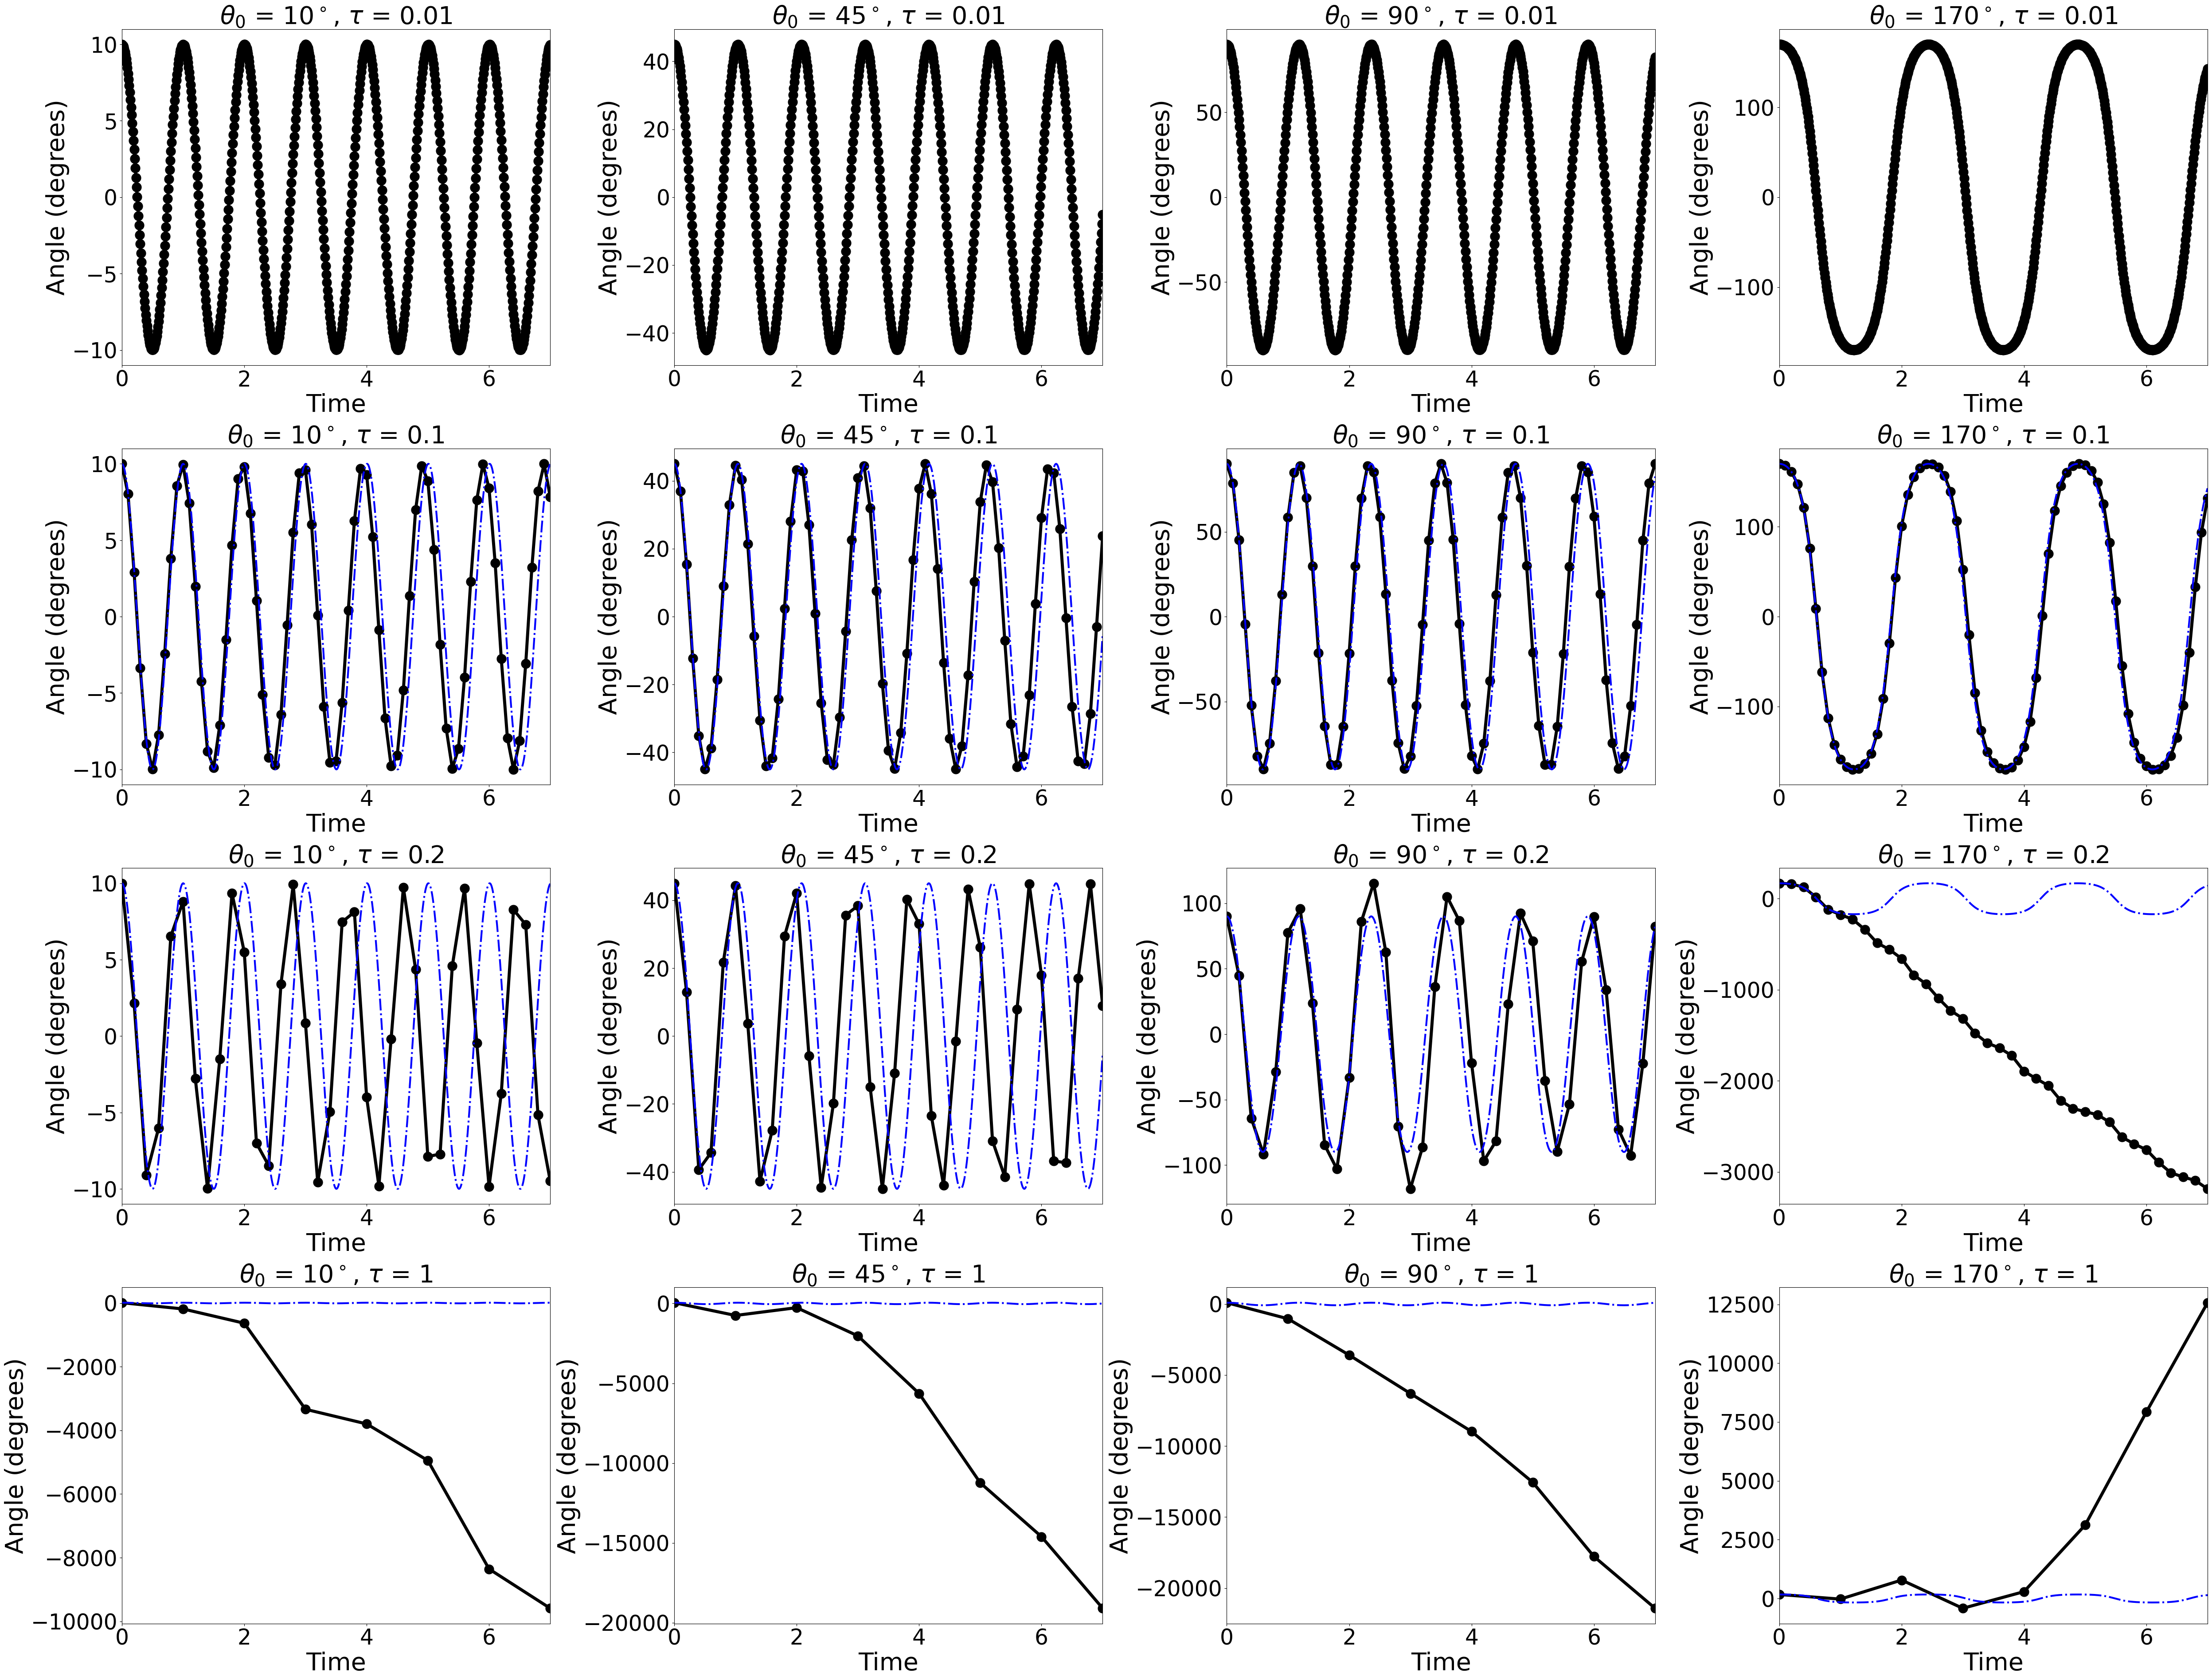

In [13]:
fig, ax = plt.subplots(4,4, figsize=(50,38))

initial_theta_array = [10, 45, 90, 170]
tau_array = [0.01, 0.1, 0.2, 1]

for i in range(len(initial_theta_array)):

    time_arrays, theta_array_tot = theta_maker(initial_theta_array[i], 'VV')
    
    # The first solution (tau=0.01) is the reference solution
    # as it's the solution with the best accuracy!
    reference_time = time_arrays[0]
    reference_theta = theta_array_tot[0]
    
    for j in range(len(time_arrays)):
        
        # Plot the current solution
        ax[j, i].plot(time_arrays[j], theta_array_tot[j], '-ok', lw=5, markersize=15)
        
        # Include the reference solution (blue dashed line) for comparison
        # (only if this isn't already the reference solution)
        if j > 0:  # Skip for the first row (tau=0.01) which is the reference
            ax[j, i].plot(reference_time, reference_theta, '-.b', lw=3)
            
        ax[j, i].tick_params(labelsize=35)
        ax[j, i].set_title(r'$\theta_0$ = ' + str(initial_theta_array[i]) 
                          + r'$^\circ$, $\tau$ = ' + str(tau_array[j]), fontsize=40)
        ax[j, i].set_xlabel('Time', fontsize=40)
        ax[j, i].set_ylabel('Angle (degrees)', fontsize=40)
        
        ax[j, i].set_xlim(0,7)

# ax[3,0].set_ylim(-5000,5000)
# ax[3,1].set_ylim(-10000,5000)
# ax[3,2].set_ylim(-10000,5000)
# ax[3,3].set_ylim(-10000,5000)

plt.tight_layout()


## <span style="color:red">Answer</span>

To use Velocity-Verlet for this problem, we need to replace the RK4 update with a V-V update.
This is done in the `theta_maker` function (and can be accessed by specifying whatMethod =
'VV'). The update step is reproduced below:

## <span style="color:red">Q4</span>
### We know that RK4 is more accurate than Velocity-Verlet in each single step, but that how much of an advantage does it give it for this simple pendulum problem?

## <span style="color:red">Answer</span>

Based on the results, the two methods have comparable accuracy for this problem. We know
that RK4 is more accurate in a single step, but that does not appear to give it much advantage
for this problem.

# Part II: Solving the Kepler problem with RK4

These questions involve modifying the code from lecture 2, which solves the Kepler problem using the Verlet method, to instead use the fourth order Runge-Kutta method.

In this question we will work with kepler_verlet.ipynb. Follow the steps outlined in Canvas Quiz to modify the code to implement fourth-order Runge-Kutta, rather than Verlet, for the circular motion test case. 

[refer to Canvas Quiz Computational Physics Lab 3 for detail]

Once you have your code working, answer the following questions.


In [14]:
def kepler_analytic(vel,T):

    #-------------------------------------------------------------------------------
    # Calculate the analytic trajectory for the Kepler central force problem.
    # Assumes an initial position r = (1,0), v = (0,vel).
    #-------------------------------------------------------------------------------
    # INPUTS:
    # - vel: the initial speed.
    # - T: sets an upper limit for |theta| for the e > 1 case (plot up to the
    #        integration time).
    #-------------------------------------------------------------------------------

    # Calculate trajectory from analytic solution

    ecc = np.linalg.norm(vel)**2 - 1        # Eccentricity
    a = 1/(1 - ecc)                         # Semi-major axis

    if ecc < 1:

        theta = np.linspace(0, 2*np.pi, 50) # Equally spaced values from 0 to 2*pi
        b = a * np.sqrt(1 - ecc**2)
        xan = -a * ecc + a * np.cos(theta)
        yan =  b * np.sin(theta)

    else:

        b = a * np.sqrt(ecc**2 - 1)
        theta_max = np.asinh(np.linsalg.norm(vel) * T/b) # Limit for range of theta
        that = np.linspace( -theta_max, theta_max, 50)
        xan = - a * ecc + a * np.cosh(theta)
        yan =   b * np.sinh(theta)

    return xan, yan

## <span style="color:red">Q5</span>

### How well does RK4 perform on the circular motion test case (initial vector ${\bf x}=[1,0,0,1]$), with the default time step ($\tau=0.05$)?

<Figure size 640x480 with 0 Axes>

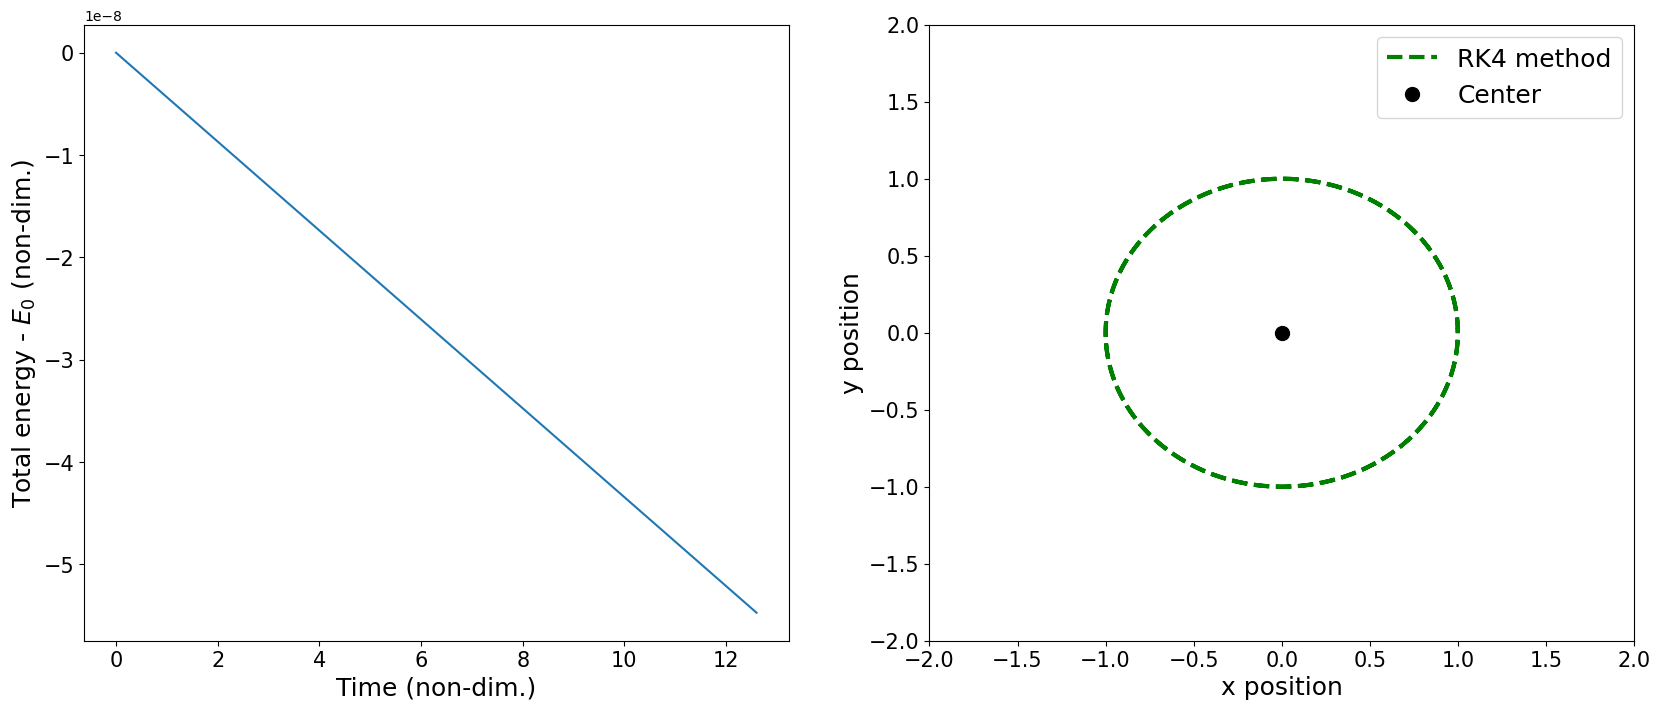

In [15]:
%matplotlib inline
plt.clf() # ignore this; this makes sure plot 
          # is cleared in widget mode

def rhs_kepler(x):

    deriv = np.zeros(4)
    
    # Extract position and velocity components
    pos_x, pos_y, vel_x, vel_y = x
    
    # Calculate r^3
    r_cubed = (pos_x**2 + pos_y**2)**1.5
    
    # Position derivatives (= velocities)
    deriv[0] = vel_x
    deriv[1] = vel_y
    
    # Velocity derivatives (= accelerations)
    deriv[2] = -pos_x/r_cubed
    deriv[3] = -pos_y/r_cubed
    
    return deriv

def rk4_kepler(tau, init_vel):

    # Set up all initial conditions:
    # Time step (non-dim.)

    # Initial position and velocity as a vector [x, y, vx, vy]
    x = np.array([1, 0, 0, init_vel])

    # Total integration time
    T = 4*np.pi

    # Number of integration steps
    numSteps = int(np.ceil(T/tau))

    # Calculate trajectory from analytic solution
    vel = x[2:4]  # Extract velocity components
    xan, yan = kepler_analytic(vel, T)

    # Preallocate vectors for speed:
    time = tau*np.arange(numSteps+1)
    pos_x = np.zeros(numSteps+1)
    pos_y = np.zeros(numSteps+1)
    energy = np.zeros(numSteps+1)

    # Initial values:
    pos_x[0] = x[0]
    pos_y[0] = x[1]
    r = np.sqrt(x[0]**2 + x[1]**2)
    speed = np.sqrt(x[2]**2 + x[3]**2)
    energy[0] = 0.5*speed**2 - 1/r

    #-------------------------------------------------------------------------------
    # RK4 method integration
    #-------------------------------------------------------------------------------
    for n in range(0, numSteps):
        # One step of RK4 method:
        f1 = rhs_kepler(x)
        f2 = rhs_kepler(x + 0.5*tau*f1)
        f3 = rhs_kepler(x + 0.5*tau*f2)
        f4 = rhs_kepler(x + tau*f3)

        # Update x vector
        x = x + tau*(f1 + 2*f2 + 2*f3 + f4)/6

        # Calculate radial position, speed and energy:
        r = np.sqrt(x[0]**2 + x[1]**2)
        speed = np.sqrt(x[2]**2 + x[3]**2)

        # Store position, time, energy:
        pos_x[n+1] = x[0]
        pos_y[n+1] = x[1]
        energy[n+1] = 0.5*speed**2 - 1/r
    
    return pos_x, pos_y, time, energy

pos_x, pos_y, time, energy = rk4_kepler(0.05, 1)
    
# Set up figure 
fig, ax = plt.subplots(1, 2, figsize=(20, 8))
    
# Left plot:
ax[0].plot(time, energy-energy[0])
ax[0].tick_params(labelsize=15)
ax[0].set_xlabel("Time (non-dim.)", fontsize=18)
ax[0].set_ylabel(r"Total energy - $E_0$ (non-dim.)", fontsize=18)

# Right plot 
ax[1].plot(pos_x, pos_y, '--g', lw=3, label="RK4 method")
ax[1].plot(0, 0, 'ko', markersize=10, label="Center")
ax[1].tick_params(labelsize=15)
ax[1].set(xlim=[-2, 2], ylim=[-2, 2])
ax[1].set_xlabel("x position", fontsize=18)
ax[1].set_ylabel("y position", fontsize=18)
ax[1].legend(fontsize=18)
plt.show();

## <span style="color:red">Answer</span>

The integration appears to be quite accurate for the circular motion test case with the default time step, τ = 0.05: the analytic trajectory is followed closely, and the variation in energy is small (≈ $10^{-7}$).

Use the same method as the second lecture, but now implement the RK4 method as opposed to Euler! Note: you need to write a rhs_kepler function too.

## <span style="color:red">Q6</span>

### Apply the RK4 scheme to simulate a highly eccentric case (v₁ = 0.3).
 
Step through orders of magnitude (e.g., τ = 0.05, 0.005, ...) to identify an estimate of the largest time step, τ, which yields a reasonably accurate orbit.

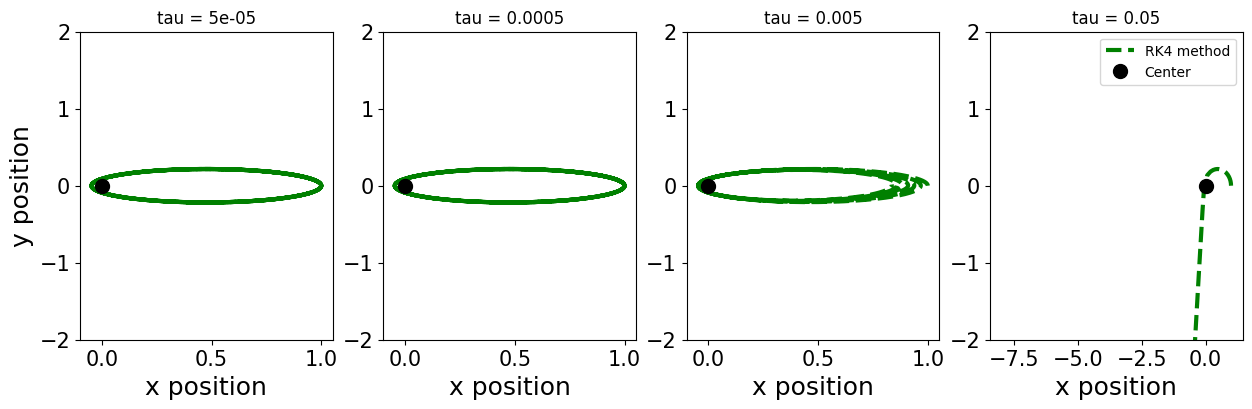

In [16]:
tau_values = [0.00005, 0.0005, 0.005, 0.05] 

# Set up figure 
fig, ax = plt.subplots(1,4, figsize=(15,4))

for i in range(4):
    
    
    pos_x, pos_y, time, energy = rk4_kepler(tau_values[i], 0.3)

    ax[i].plot(pos_x, pos_y, '--g', lw=3, label="RK4 method" if i==3 else None)
    ax[i].plot(0, 0, 'ko', markersize=10, label="Center" if i==3 else None)
    ax[i].tick_params(labelsize=15)
    ax[i].set_ylim(-2, 2)
    ax[i].set_xlabel("x position", fontsize=18)
    ax[i].set_title(f"tau = {tau_values[i]}")
    

ax[0].set_ylabel("y position", fontsize=18)
ax[3].legend(fontsize=10)


## <span style="color:red">Answer</span>

The Verlet method fails (the orbit diverges) with the default time step, τ = 0.05, for this case (as we found in Lab 2), and a time step as small as τ = 0.0005 was needed for accurate integration. 

RK4 also fails for this case with the default time step of τ = 0.05 (`rk4_kepler(0.05,0.3)`). A time step as small as τ = 0.001 is needed for accurate integration (`rk4_kepler(0.001,0.3)`). Intermediate time steps give inaccurate, but quite fun behavior. Testing in factors of ten from 0.05, the first accurate integration is at τ = 0.0005.

## <span style="color:red">Q7</span>

### Apply the RK4 scheme to simulate a highly eccentric initial condition, $\mathbf{x}=[1,0,0,0.3]$, from Question 6.


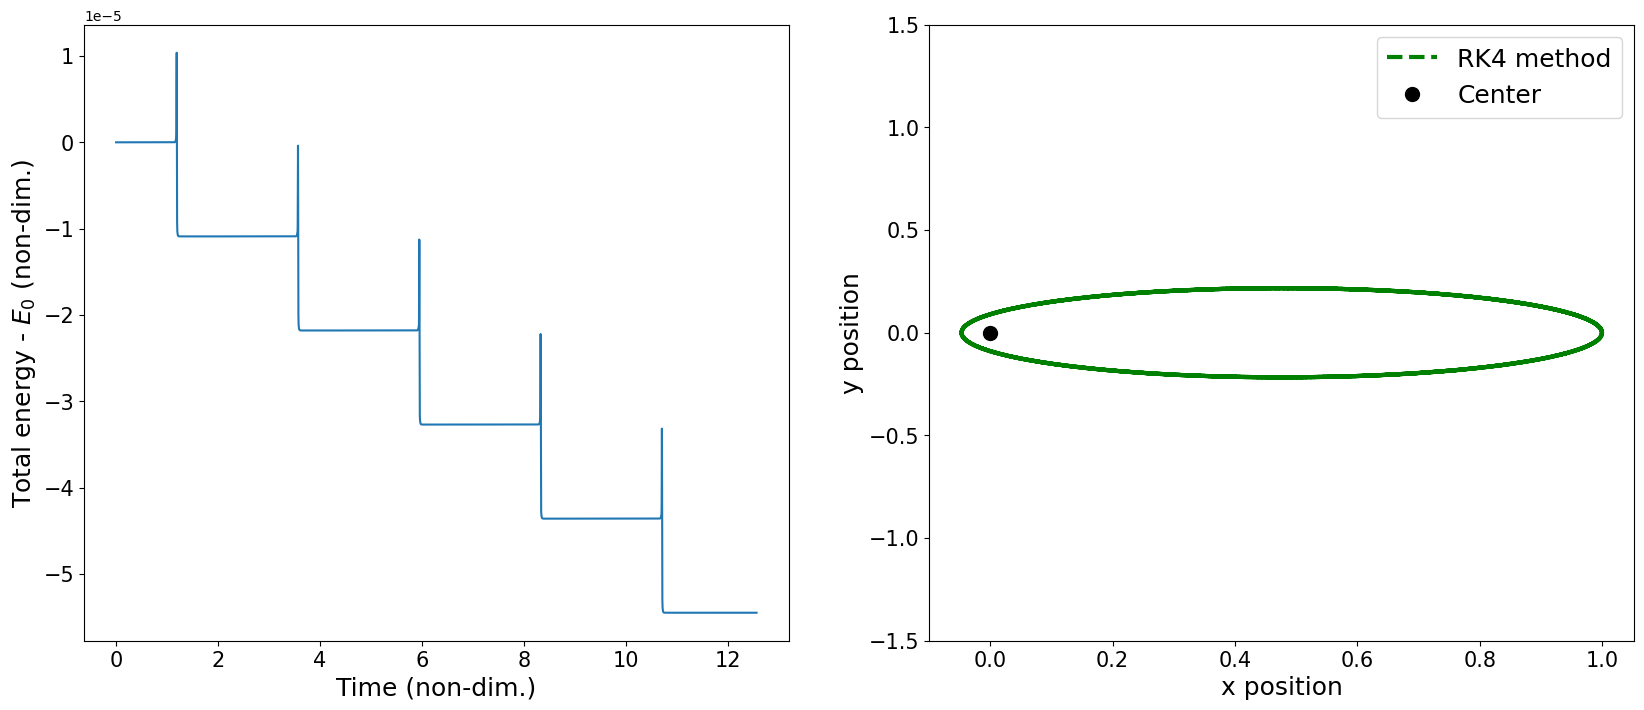

In [17]:
pos_x, pos_y, time, energy = rk4_kepler(0.001, 0.3)
    
# Set up figure 
fig, ax = plt.subplots(1, 2, figsize=(20, 8))
    
# Left plot:
ax[0].plot(time, energy-energy[0])
ax[0].tick_params(labelsize=15)
ax[0].set_xlabel("Time (non-dim.)", fontsize=18)
ax[0].set_ylabel(r"Total energy - $E_0$ (non-dim.)", fontsize=18)

# Right plot 
ax[1].plot(pos_x, pos_y, '--g', lw=3, label="RK4 method")
ax[1].plot(0, 0, 'ko', markersize=10, label="Center")
ax[1].tick_params(labelsize=15)
ax[1].set_ylim(-1.5, 1.5)
ax[1].set_xlabel("x position", fontsize=18)
ax[1].set_ylabel("y position", fontsize=18)
ax[1].legend(fontsize=18)
plt.show();

## <span style="color:red">Answer</span>

You can produce this figure by running, e.g., rk4_kepler(0.001,0.3),

**Marking notes**

- 2 points: correct figure as on the right with the central star, orbit, and correct labels
- 1 point: some issues with the labels or missing centre
- 0 points: missing or incorrect figure

## <span style="color:red">Q8</span>

### Summarize the comparison of RK4 to the Verlet method on the Kepler problem.

## <span style="color:red">Answer</span>

The two methods have different advantages: RK4 is a bit more accurate for a given time step,
but Verlet conserves energy over an orbit.